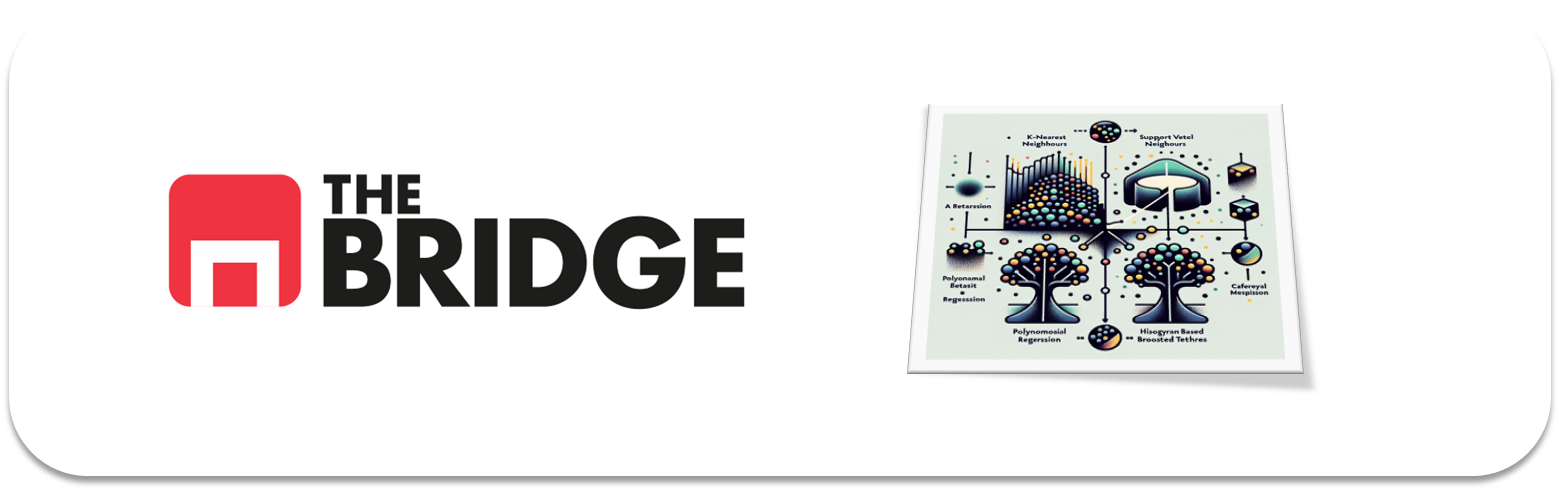

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de **clasificación** y un problema de **regresión**.
* **Clasificación**: predecir la **calidad** del vino (target categórico) a partir de las propiedades fisicoquímicas.
* **Regresión**: predecir el **grado alcohólico** del vino a partir del resto de propiedades.
* Objetivo de negocio (clasificación): anticipar la clasificación por catadores para planificar producción, distribución y precio; métrica relevante = **recall medio**.
* Objetivo de negocio (regresión): equivocarse lo menos posible **porcentualmente** sobre el grado alcohólico; métrica relevante = **MAPE**.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, mean_absolute_percentage_error,
    r2_score, accuracy_score, f1_score, classification_report, confusion_matrix, make_scorer
)
from sklearn.metrics import ConfusionMatrixDisplay

RANDOM_STATE = 42

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

### #1 Dataset y carga de datos

In [ ]:
data_path = "./data/wines_dataset.csv"
df = pd.read_csv(data_path, sep="|")
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.210,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.160,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.180,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.260,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.630,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red
5,5.7,0.265,0.28,6.90,0.036,46.0,150.0,0.99299,3.36,0.44,10.8,7,white
6,6.6,0.210,0.31,11.40,0.039,46.0,165.0,0.99795,3.41,0.44,9.8,7,white
7,6.7,0.310,0.30,2.10,0.038,18.0,130.0,0.99280,3.36,0.63,10.6,6,white
8,8.9,0.750,0.14,2.50,0.086,9.0,30.0,0.99824,3.34,0.64,10.5,5,red
9,7.5,0.420,0.20,1.40,0.060,15.0,168.0,0.99440,3.06,0.40,9.4,6,white


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [ ]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
class                   0
dtype: int64

In [ ]:
target_clf = "quality"
target_reg = "alcohol"
print("Distribución quality:", df[target_clf].value_counts().sort_index().to_dict())

Distribución quality: {3: 30, 4: 216, 5: 2138, 6: 2836, 7: 1079, 8: 193, 9: 5}


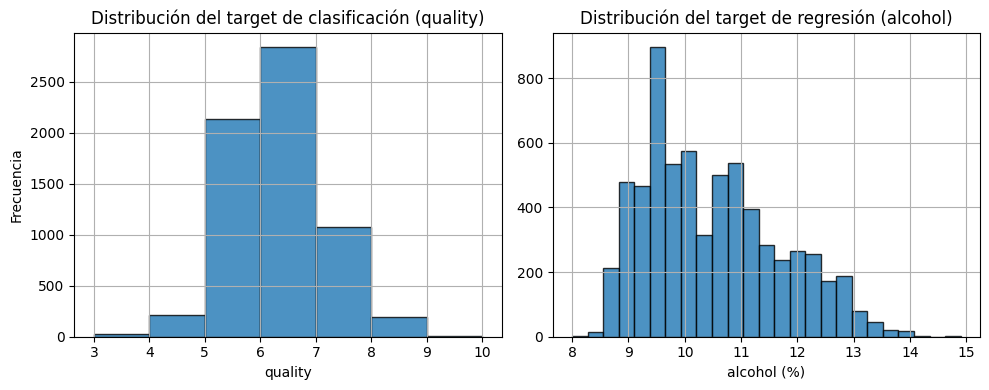

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df[target_clf].hist(bins=range(3, 11), ax=axes[0], edgecolor="black", alpha=0.8)
axes[0].set_title("Distribución del target de clasificación (quality)")
axes[0].set_xlabel("quality")
axes[0].set_ylabel("Frecuencia")
df[target_reg].hist(ax=axes[1], bins=25, edgecolor="black", alpha=0.8)
axes[1].set_title("Distribución del target de regresión (alcohol)")
axes[1].set_xlabel("alcohol (%)")
plt.tight_layout()
plt.show()

**Interpretación**: La calidad está concentrada en 5–6, con desbalance de clases; el alcohol es aproximadamente unimodal. Para clasificación conviene tener en cuenta el recall por clase (recall medio); para regresión usaremos MAPE.

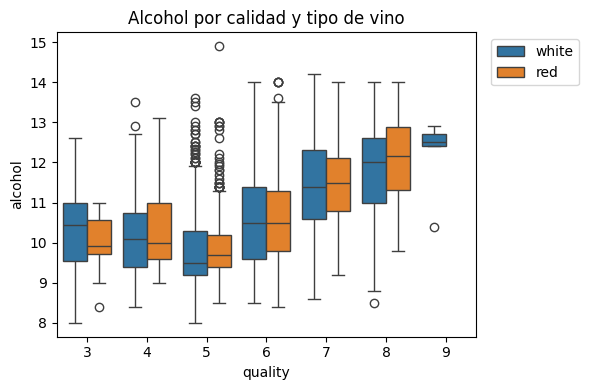

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x=target_clf, y=target_reg, hue="class", ax=ax)
ax.set_title("Alcohol por calidad y tipo de vino")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### #1.1 Preprocesamiento

Para ambos problemas usamos variables numéricas; codificamos `class` (red/white) con LabelEncoder para incluirlo como feature. Escalado con StandardScaler dentro de pipelines donde haga falta (LogReg, KNN).

In [ ]:
df_work = df.copy()
le = LabelEncoder()
df_work["class_enc"] = le.fit_transform(df_work["class"])  # 0/1

feature_cols_clf = [c for c in df_work.columns if c not in [target_clf, "class"]]
feature_cols_reg = [c for c in df_work.columns if c not in [target_reg, "class"]]

X_clf = df_work[feature_cols_clf]
y_clf = df_work[target_clf]
X_reg = df_work[feature_cols_reg]
y_reg = df_work[target_reg]

print("Clasificación: X shape", X_clf.shape, "y shape", y_clf.shape)
print("Regresión: X shape", X_reg.shape, "y shape", y_reg.shape)

Clasificación: X shape (6497, 12) y shape (6497,)
Regresión: X shape (6497, 12) y shape (6497,)


In [ ]:
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=RANDOM_STATE
)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)
print("Train/Test splits listos.")

Train/Test splits listos.


### #2 Modelado para clasificación

Objetivo: maximizar el **recall medio** (f1_macro). Comparamos al menos tres modelos; KNN como baseline con al menos 2 valores de K. Usamos `class_weight='balanced'` para paliar el desbalance. Validación cruzada StratifiedKFold y, para el modelo elegido, optimización con GridSearchCV.

In [ ]:
scaler_clf = StandardScaler()
X_clf_train_s = scaler_clf.fit_transform(X_clf_train)
X_clf_test_s = scaler_clf.transform(X_clf_test)

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_10 = KNeighborsClassifier(n_neighbors=10)
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)

pipe_lr.fit(X_clf_train, y_clf_train)
knn_5.fit(X_clf_train_s, y_clf_train)
knn_10.fit(X_clf_train_s, y_clf_train)
rf_clf.fit(X_clf_train, y_clf_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [ ]:
def eval_clf(name, model, use_scaled=False):
    X_ = X_clf_test_s if use_scaled else X_clf_test
    pred = model.predict(X_)
    return {
        "model": name,
        "accuracy": accuracy_score(y_clf_test, pred),
        "f1_macro": f1_score(y_clf_test, pred, average="macro"),
    }

results_clf = [
    eval_clf("LogReg", pipe_lr, use_scaled=False),
    eval_clf("KNN_5", knn_5, use_scaled=True),
    eval_clf("KNN_10", knn_10, use_scaled=True),
    eval_clf("RF", rf_clf, use_scaled=False),
]
df_res_clf = pd.DataFrame(results_clf).set_index("model")
df_res_clf

,accuracy,f1_macro
model,,
LogReg,0.313846,0.210312
KNN_5,0.543846,0.243124
KNN_10,0.566923,0.254451
RF,0.671538,0.381316


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = []
for name, model, use_scaled in [("LogReg", pipe_lr, False), ("KNN_5", knn_5, True), ("KNN_10", knn_10, True), ("RF", rf_clf, False)]:
    scores = []
    for train_idx, val_idx in skf.split(X_clf_train, y_clf_train):
        Xt, Xv = X_clf_train.iloc[train_idx], X_clf_train.iloc[val_idx]
        yt, yv = y_clf_train.iloc[train_idx], y_clf_train.iloc[val_idx]
        if use_scaled:
            sc = StandardScaler()
            Xt = sc.fit_transform(Xt)
            Xv = sc.transform(Xv)
        model.fit(Xt, yt)
        pred = model.predict(Xv)
        scores.append(f1_score(yv, pred, average="macro"))
    cv_scores.append({"model": name, "f1_macro_mean": np.mean(scores), "f1_macro_std": np.std(scores)})
pd.DataFrame(cv_scores).set_index("model")

,f1_macro_mean,f1_macro_std
model,,
LogReg,0.219742,0.012687
KNN_5,0.301740,0.033584
KNN_10,0.278068,0.033138
RF,0.393743,0.039794


Optimización de hiperparámetros del modelo elegido (Random Forest) con GridSearchCV (scoring = recall medio).

In [ ]:
param_grid_rf = {
    "n_estimators": [80, 120],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [2, 5],
    "max_features": ["sqrt", 0.5],
}
rf_base = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
grid_clf = GridSearchCV(rf_base, param_grid_rf, scoring=make_scorer(f1_score, average="macro"), cv=skf, n_jobs=-1)
grid_clf.fit(X_clf_train, y_clf_train)
best_clf = grid_clf.best_estimator_
print("Mejores parámetros:", grid_clf.best_params_)
print("Test f1_macro:", f1_score(y_clf_test, best_clf.predict(X_clf_test), average="macro"))

Mejores parámetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 80}
Test f1_macro: 0.3263127523490451


### Evaluación del modelo de clasificación

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.20      0.23      0.22        43
           5       0.61      0.70      0.65       428
           6       0.63      0.42      0.51       567
           7       0.43      0.67      0.52       216
           8       0.36      0.41      0.39        39
           9       0.00      0.00      0.00         1

    accuracy                           0.55      1300
   macro avg       0.32      0.35      0.33      1300
weighted avg       0.57      0.55      0.54      1300



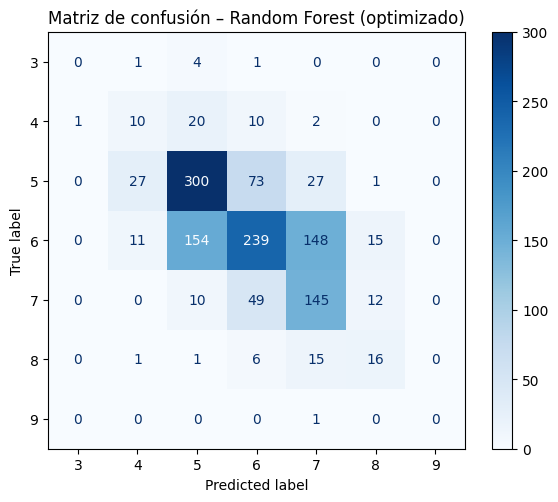

In [ ]:
y_clf_pred = best_clf.predict(X_clf_test)
print(classification_report(y_clf_test, y_clf_pred))
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_clf_test, y_clf_pred, ax=ax, cmap="Blues")
ax.set_title("Matriz de confusión – Random Forest (optimizado)")
plt.tight_layout()
plt.show()

**Interpretación**: La matriz y el report muestran en qué clases (calidades) el modelo acierta más o menos. Las clases minoritarias (3, 4, 8, 9) suelen tener menor recall; el recall medio mejora con class_weight y con el modelo elegido.

### #3 Modelado para regresión

Objetivo: predecir el grado alcohólico con el menor MAPE posible. Comparamos al menos tres modelos (p. ej. regresión lineal, KNN, Random Forest) y usamos validación cruzada con MAPE.

In [ ]:
def reg_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

pipe_lr_reg = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
pipe_knn_reg = Pipeline([("scaler", StandardScaler()), ("model", KNeighborsRegressor(n_neighbors=5))])
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)

pipe_lr_reg.fit(X_reg_train, y_reg_train)
pipe_knn_reg.fit(X_reg_train, y_reg_train)
rf_reg.fit(X_reg_train, y_reg_train)

results_reg = [
    {"model": "LinearReg", **reg_metrics(y_reg_test, pipe_lr_reg.predict(X_reg_test))},
    {"model": "KNN_5", **reg_metrics(y_reg_test, pipe_knn_reg.predict(X_reg_test))},
    {"model": "RF", **reg_metrics(y_reg_test, rf_reg.predict(X_reg_test))},
]
df_res_reg = pd.DataFrame(results_reg).set_index("model")
df_res_reg

,MAE,RMSE,MAPE,R2
model,,,,
LinearReg,0.355298,0.472255,0.034217,0.841747
KNN_5,0.419521,0.583417,0.039283,0.758478
RF,0.270799,0.406875,0.025700,0.882532


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_mape = []
for name, model in [("LinearReg", pipe_lr_reg), ("KNN_5", pipe_knn_reg), ("RF", rf_reg)]:
    scores = []
    for train_idx, val_idx in kf.split(X_reg_train):
        Xt, Xv = X_reg_train.iloc[train_idx], X_reg_train.iloc[val_idx]
        yt, yv = y_reg_train.iloc[train_idx], y_reg_train.iloc[val_idx]
        model.fit(Xt, yt)
        scores.append(mean_absolute_percentage_error(yv, model.predict(Xv)))
    cv_mape.append({"model": name, "MAPE_mean": np.mean(scores), "MAPE_std": np.std(scores)})
pd.DataFrame(cv_mape).set_index("model")

,MAPE_mean,MAPE_std
model,,
LinearReg,0.033694,0.000558
KNN_5,0.042124,0.000686
RF,0.027077,0.000500


Evaluación del modelo elegido (Random Forest) y análisis breve de errores.

Métricas finales (RF): {'MAE': 0.2878159753888639, 'RMSE': np.float64(0.421146068844185), 'MAPE': 0.0272804851599244, 'R2': 0.8741468946151767}


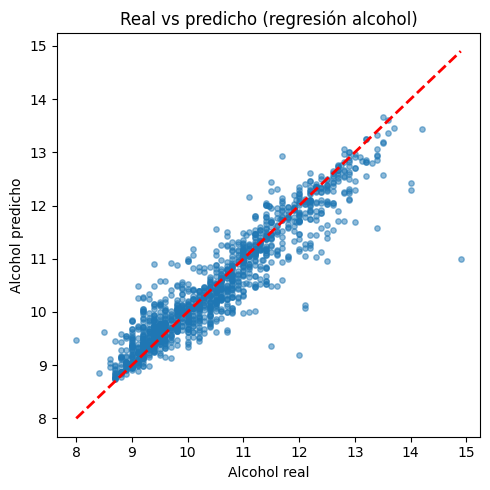

In [ ]:
y_reg_pred = rf_reg.predict(X_reg_test)
print("Métricas finales (RF):", reg_metrics(y_reg_test, y_reg_pred))

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_reg_test, y_reg_pred, alpha=0.5, s=15)
ax.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], "r--", lw=2)
ax.set_xlabel("Alcohol real")
ax.set_ylabel("Alcohol predicho")
ax.set_title("Real vs predicho (regresión alcohol)")
plt.tight_layout()
plt.show()

**Análisis de errores**: Los puntos alejados de la diagonal son subestimaciones o sobreestimaciones del grado alcohólico; suelen concentrarse en rangos donde hay más variabilidad (p. ej. calidades extremas).

In [ ]:
# =============================================================================
# RESUMEN
# =============================================================================

print("=" * 60)
print("RESUMEN — Práctica Repaso Supervisado (Wine Quality)")
print("=" * 60)

# Clasificación:
mejor_clf = df_res_clf["f1_macro"].idxmax()
print("\n # TAREA 1 — CLASIFICACIÓN (target = quality)")
print(f"   Mejor modelo: {mejor_clf}")
print(f"   Accuracy (test): {df_res_clf.loc[mejor_clf, 'accuracy']:.4f}")
print(f"   F1-macro (test): {df_res_clf.loc[mejor_clf, 'f1_macro']:.4f}")

# Regresión:
mejor_reg = df_res_reg["MAPE"].idxmin()
print("\n # TAREA 2 — REGRESIÓN (target = alcohol)")
print(f"   Mejor modelo: {mejor_reg}")
print(f"   RMSE (test): {df_res_reg.loc[mejor_reg, 'RMSE']:.4f}")
print(f"   R² (test): {df_res_reg.loc[mejor_reg, 'R2']:.4f}")
print(f"   MAPE (test): {df_res_reg.loc[mejor_reg, 'MAPE']:.4f}")

print("\n # CONCLUSIÓN BREVE")
print("   - Clasificación: el modelo elegido maximiza el recall \nmedio (F1-macro) en la predicción de calidad.")
print("   - Regresión: el modelo elegido minimiza el error porcentual \n(MAPE) en la predicción del grado alcohólico.")
print("=" * 60)

RESUMEN — Práctica Repaso Supervisado (Wine Quality)

 # TAREA 1 — CLASIFICACIÓN (target = quality)
   Mejor modelo: RF
   Accuracy (test): 0.6715
   F1-macro (test): 0.3813

 # TAREA 2 — REGRESIÓN (target = alcohol)
   Mejor modelo: RF
   RMSE (test): 0.4069
   R² (test): 0.8825
   MAPE (test): 0.0257

 # CONCLUSIÓN BREVE
   - Clasificación: el modelo elegido maximiza el recall 
medio (F1-macro) en la predicción de calidad.
   - Regresión: el modelo elegido minimiza el error porcentual 
(MAPE) en la predicción del grado alcohólico.


### #6 Conclusión

* Clasificación (quality): Se seleccionó Random Forest porque obtiene el mejor rendimiento general en la predicción de la calidad del vino. Usamos recall medio para evaluar el modelo, ya que permite medir cómo de bien se clasifican todas las clases en conjunto.

* Regresión (alcohol): También se eligió Random Forest, ya que ofrece un buen equilibrio entre las métricas de error (MAE, MAPE) y un $R^2$ alto, lo que indica que el modelo predice bastante bien el grado alcohólico.

* Posibles mejoras: Se podría mejorar la clasificación equilibrando las clases o creando nuevas variables. Para la regresión, se podrían probar otros modelos como Gradient Boosting o ajustar más los hiperparámetros.